# Analisis Post-Entrenamiento del Sparse Autoencoder (SAE)

Este notebook toma los embeddings visuales extraidos por el modelo RemoteCLIP+LoRA (del notebook `sit2_geovision_clip.ipynb`) y entrena un Sparse Autoencoder (SAE) para obtener representaciones latentes interpretables y dispersas.

## Flujo de trabajo
- Extraccion de features visuales (512-d) desde el checkpoint fine-tuned de RemoteCLIP
- Entrenamiento de un SAE con arquitectura sobreparametrizada (512 -> 2048 -> 512)
- Analisis de interpretabilidad: neuronas por clase, correlaciones ambientales
- Validacion estadistica: AFE (exploratorio) y AFC (confirmatorio) sobre los embeddings
- Exportacion de artefactos: checkpoints, embeddings, manifest, metricas

## Metricas objetivo (KPI de la situacion 2)
- **Sparsity ratio SAE**: >= 0.70 (minimo), >= 0.85 (excelente)
- **Loss reconstruccion SAE**: <= 0.05 (minimo), <= 0.02 (excelente)
- **Varianza explicada AFE**: >= 80%
- **RMSEA (AFC)**: < 0.08
- **CFI (AFC)**: > 0.90


In [1]:
# @title 1. Dependencias
# Sit.2 — SAE post-entrenamiento (features del checkpoint `sit2_geovision_clip`)

%pip install -q huggingface_hub open_clip_torch zarr numcodecs pandas pyarrow numpy scipy scikit-learn
%pip install -q torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 6.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 45.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Configuracion de rutas y semillas

Se configuran los directorios de salida, las semillas para reproducibilidad, y se sincronizan los artefactos del modelo CLIP base (checkpoint `best.pt`, logs de entrenamiento, curvas) desde las posibles ubicaciones de Colaab, Drive, Kaggle o local.

### Directorios de salida
- `OUT_DIR`: raiz del experimento SAE
- `CLIP_DIR`: copia de los artefactos del modelo CLIP base
- `EMB_DIR`: embeddings extraidos (formato .pt)
- `ANALISIS_DIR`: resultados de AFE, AFC, correlaciones, heatmaps


In [2]:
# @title 2. Configurar rutas + traer artefactos de sit2_geovision_clip
# Ruta manual (Kaggle/local) si no hay Colab/Drive:
CKPT_PATH_MANUAL = "/kaggle/input/pesos-pt/best.pt"

HF_REPO_ID = "Slucu-0310/geovision-cali-sit2"
SEED = 42

import os, sys, json, hashlib, shutil, zipfile
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm

np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

OUT_DIR = Path("/content/runs/sit2_sae")
CLIP_DIR = OUT_DIR / "clip_modelo"
EMB_DIR = OUT_DIR / "embeddings"
ANALISIS_DIR = OUT_DIR / "analisis"
for d in (OUT_DIR, CLIP_DIR, EMB_DIR, ANALISIS_DIR):
    d.mkdir(parents=True, exist_ok=True)

CLIP_FILES = (
    "best.pt",
    "training_logs.json",
    "training_history.json",
    "training_curves.png",
    "metadata.json",
    "hashes.sha256",
)

def _copy_if_newer(src: Path, dst: Path) -> bool:
    if not src.is_file():
        return False
    if dst.is_file() and dst.stat().st_mtime >= src.stat().st_mtime:
        return False
    shutil.copy2(src, dst)
    return True

def sync_clip_artifacts() -> list[str]:
    """Copia salidas de sit2_geovision_clip.ipynb a clip_modelo/."""
    copied = []
    sources = [
        Path("/content/runs/sit2_recall_final"),
        Path("/content/geovision_clip_modelo_final"),
        Path("/content/drive/MyDrive/geovision-cali/sit2_geovision_clip"),
    ]
    zip_clip = Path("/content/geovision_clip_modelo_final.zip")
    if zip_clip.is_file() and not (CLIP_DIR / "best.pt").is_file():
        with zipfile.ZipFile(zip_clip) as zf:
            zf.extractall(CLIP_DIR)
            copied.append(str(zip_clip))

    try:
        from google.colab import drive
        if not Path("/content/drive").is_dir():
            drive.mount("/content/drive", force_remount=False)
    except Exception:
        pass

    for root in sources:
        if not root.exists():
            continue
        for name in CLIP_FILES:
            if _copy_if_newer(root / name, CLIP_DIR / name):
                copied.append(name)
        curvas_src = root / "curvas"
        if curvas_src.is_dir():
            shutil.copytree(curvas_src, CLIP_DIR / "curvas", dirs_exist_ok=True)
            copied.append("curvas/")

    manual = Path(CKPT_PATH_MANUAL)
    if manual.is_file() and _copy_if_newer(manual, CLIP_DIR / "best.pt"):
        copied.append("best.pt (manual)")

    if not (CLIP_DIR / "best.pt").is_file() and Path("/kaggle/input").exists():
        cand = sorted(Path("/kaggle/input").rglob("best.pt"), key=os.path.getmtime, reverse=True)
        if cand and _copy_if_newer(cand[0], CLIP_DIR / "best.pt"):
            copied.append(f"best.pt ({cand[0]})")

    if not (CLIP_DIR / "best.pt").is_file() and Path("/content/runs").exists():
        for p in sorted(Path("/content/runs").rglob("best.pt"), key=os.path.getmtime, reverse=True):
            if "sit2_sae" in str(p):
                continue
            if _copy_if_newer(p, CLIP_DIR / "best.pt"):
                copied.append(f"best.pt ({p})")
                break

    return copied

copied = sync_clip_artifacts()
CKPT = CLIP_DIR / "best.pt"
if not CKPT.is_file():
    raise FileNotFoundError(
        "No hay best.pt del notebook sit2_geovision_clip. "
        "Ejecuta entrenar + export en Colab, monta Drive, o sube el zip/dataset a Kaggle."
    )
print(f"Checkpoint CLIP: {CKPT} ({CKPT.stat().st_size / 1e6:.1f} MB)")
print(f"clip_modelo/: {[p.name for p in sorted(CLIP_DIR.iterdir())]}")
if copied:
    print("Sincronizado:", sorted(set(copied)))

Device: cuda
Checkpoint CLIP: /content/runs/sit2_sae/clip_modelo/best.pt (635.3 MB)
clip_modelo/: ['best.pt']
Sincronizado: ['best.pt (/kaggle/input/datasets/samuelpatino/pesos-pt/best.pt)']


## Carga del dataset desde Hugging Face

Se descarga el dataset `Slucu-0310/geovision-cali-sit2` que contiene:
- `metadatos.parquet`: 2263 filas con metadatos (clase, coordenadas, indices, contaminantes)
- `tiles.zarr`: array (2263, 13, 64, 64) con los tiles Sentinel-2 (12 bandas + SCL)
- `secuencias.json`: 30 secuencias temporales de 8 fechas para la Situacion 3

Se aplica el mismo split estratificado 70/15/15 con SEED=42 que en el notebook CLIP.
Se calculan estadisticas de normalizacion (media y std por banda) sobre una muestra de 512 tiles.


In [4]:
# @title 3. Descargar dataset desde HF
from huggingface_hub import snapshot_download
import pandas as pd
import zarr

DATA_DIR = Path("/content/dataset_sit2")
if not (DATA_DIR / "metadatos.parquet").is_file():
    print("Descargando dataset desde HF...")
    try:
        from google.colab import userdata
        os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
    except:
        pass
    from huggingface_hub import login
    if os.environ.get("HF_TOKEN"):
        login(token=os.environ["HF_TOKEN"], add_to_git_credential=False)
    snapshot_download(
        repo_id=HF_REPO_ID, repo_type="dataset",
        local_dir=str(DATA_DIR), local_dir_use_symlinks=False
    )
else:
    print("Dataset ya descargado")

# Cargar metadatos
df = pd.read_parquet(DATA_DIR / "metadatos.parquet")
print(f"Pares: {len(df)}")

# Cargar tiles
store = zarr.storage.LocalStore(str(DATA_DIR / "tiles.zarr"))
tiles_z = zarr.open(store, mode="r")
if isinstance(tiles_z, zarr.Group):
    tiles_z = tiles_z["tiles"]
print(f"Tiles shape: {tiles_z.shape}")

# Split estratificado (misma semilla que notebook principal)
from sklearn.model_selection import train_test_split
if "split" not in df.columns:
    ti, tmp = train_test_split(np.arange(len(df)), test_size=0.30, stratify=df["clase"].values, random_state=42)
    vi, te = train_test_split(tmp, test_size=0.50, stratify=df.iloc[tmp]["clase"].values, random_state=42)
    df["split"] = "train"; df.loc[vi, "split"] = "val"; df.loc[te, "split"] = "test"

CLASES = ["contaminacion_alta_NO2", "contaminacion_alta_SO2", "ozono_anomalo",
          "vegetacion_densa", "suelo_urbano"]
CLASE_A_IDX = {c: i for i, c in enumerate(CLASES)}

# Normalizacion stats
rng = np.random.default_rng(42)
ns = min(512, int(tiles_z.shape[0]))
ix = rng.choice(int(tiles_z.shape[0]), ns, replace=False)
sm = np.stack([np.asarray(tiles_z[i], dtype=np.float32) for i in ix])
bm = sm.mean(axis=(0,2,3)).astype(np.float32)
bs = np.maximum(sm.std(axis=(0,2,3)), 1e-3).astype(np.float32)
print(f"Stats computed: mean={bm.shape}, std={bs.shape}")

Dataset ya descargado
Pares: 2263
Tiles shape: (2263, 13, 64, 64)
Stats computed: mean=(13,), std=(13,)


## Extraccion de embeddings visuales con RemoteCLIP

Se carga el modelo RemoteCLIP ViT-B/32 con los pesos pre-entrenados de chendelong/RemoteCLIP, se adapta la primera capa convolucional de 3 a 12 canales (asignando RGB a los canales 1,2,3 y distribuyendo el promedio al resto), y se cargan los pesos fine-tuned del clasificador (checkpoint de `sit2_geovision_clip`).

Luego se extraen features para todos los 2263 tiles: cada tile se normaliza, se interpola a 224x224, se pasa por el visual encoder, y se obtiene un embedding L2-normalizado de 512 dimensiones.

### Archivos generados
- `visual_512.pt`: tensor (2263, 512) con los embeddings + labels + metadatos
- `features.pt`: version legacy con solo features y labels
- `manifest.json`: metadatos de los archivos generados


In [5]:
# @title 4. Cargar checkpoint + extraer features
import open_clip
from huggingface_hub import hf_hub_download

# --- Cargar RemoteCLIP ---
cm, _, _ = open_clip.create_model_and_transforms("ViT-B-32", pretrained=None)
cp_remote = hf_hub_download("chendelong/RemoteCLIP", "RemoteCLIP-ViT-B-32.pt",
                            cache_dir="/content/checkpoints")
cm.load_state_dict(torch.load(cp_remote, map_location="cpu"), strict=False)

# --- Adaptar conv1 a 12 canales ---
oc = cm.visual.conv1
nc = nn.Conv2d(12, oc.out_channels, oc.kernel_size,
               stride=oc.stride, padding=oc.padding, bias=False)
with torch.no_grad():
    ir, ig, ib = 3, 2, 1
    w = nc.weight.data
    w[:,ir] = oc.weight[:,0]
    w[:,ig] = oc.weight[:,1]
    w[:,ib] = oc.weight[:,2]
    wm = oc.weight.mean(dim=1, keepdim=False)
    for b in range(12):
        if b not in (ir, ig, ib):
            w[:,b] = wm * (3.0/12)
    nc.weight.copy_(w)
cm.visual.conv1 = nc

# --- Cargar pesos fine-tuned ---
state = torch.load(CKPT, map_location="cpu")
if "cm" in state:
    cm.load_state_dict(state["cm"], strict=False)
elif "clip_model" in state:
    cm.load_state_dict(state["clip_model"], strict=False)
else:
    # checkpoint solo con visual encoder?
    cm.load_state_dict(state, strict=False)

cm = cm.to(DEVICE)
cm.eval()
print("Checkpoint cargado. Visual encoder listo.")

# --- Extraer features de todos los tiles ---
BATCH_SIZE = 64
print("Extrayendo features de todos los tiles...")
all_feats = []
all_labels = []

with torch.no_grad():
    for i in tqdm(range(0, len(df), BATCH_SIZE), desc="Features"):
        batch_idx = slice(i, min(i + BATCH_SIZE, len(df)))
        batch_tiles = []
        for j in range(batch_idx.start, batch_idx.stop):
            t = np.asarray(tiles_z[j], dtype=np.float32)
            t = (t - bm.reshape(13,1,1)) / bs.reshape(13,1,1)
            batch_tiles.append(t[:12])  # 12 bandas
        tiles = torch.from_numpy(np.stack(batch_tiles)).float().to(DEVICE)
        tiles_224 = F.interpolate(tiles, size=(224, 224), mode="bilinear", align_corners=False)
        feats = F.normalize(cm.visual(tiles_224), dim=-1)
        all_feats.append(feats.cpu())
        all_labels.extend(df.iloc[batch_idx]["clase"].values)

features = torch.cat(all_feats, dim=0)  # (N, 512)
labels = np.array(all_labels)
print(f"Features extraidas: {features.shape}")

feat_path = EMB_DIR / "visual_512.pt"
torch.save({
    "features": features,
    "labels": labels,
    "clases": CLASES,
    "df_index": df.index.tolist(),
    "split": df["split"].tolist() if "split" in df.columns else None,
    "bm": bm,
    "bs": bs,
    "checkpoint_clip": str(CKPT),
}, feat_path)
legacy = OUT_DIR / "features.pt"
torch.save({"features": features, "labels": labels, "bm": bm, "bs": bs}, legacy)

manifest = {
    "n_samples": int(len(df)),
    "feature_dim": 512,
    "dataset": HF_REPO_ID,
    "files": {
        "visual_embeddings": str(feat_path),
        "legacy_features": str(legacy),
        "clip_checkpoint": str(CLIP_DIR / "best.pt"),
    },
}
(EMB_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
print(f"Embeddings: {feat_path}")
print(f"Manifest: {EMB_DIR / 'manifest.json'}")

print(f"Feature mean abs: {features.abs().mean():.4f}")
print(f"Feature std: {features.std():.4f}")

RemoteCLIP-ViT-B-32.pt:   0%|          | 0.00/605M [00:00<?, ?B/s]

Checkpoint cargado. Visual encoder listo.
Extrayendo features de todos los tiles...


Features:   0%|          | 0/36 [00:00<?, ?it/s]

Features extraidas: torch.Size([2263, 512])
Embeddings: /content/runs/sit2_sae/embeddings/visual_512.pt
Manifest: /content/runs/sit2_sae/embeddings/manifest.json
Feature mean abs: 0.0295
Feature std: 0.0441


## Entrenamiento del Sparse Autoencoder (SAE)

### Arquitectura
El SAE utiliza una capa oculta **4 veces mas ancha** que la entrada (512 -> 2048 -> 512), siguiendo las recomendaciones de la literatura de interpretabilidad mecanica (Anthropic, Cunningham et al.). Esta sobreparametrizacion permite que el codigo latente aprenda features mas especificos y separables.

### Funcion de perdida
```
Loss = MSE_reconstruccion + lambda_L1 * L1(hidden)
```
Donde L1 es la media del valor absoluto de las activaciones, que fuerza a que la mayoria de las 2048 neuronas permanezcan inactivas (sparsity).

### Tecnicas de entrenamiento
- **CosineAnnealingLR**: programa la tasa de aprendizaje con decrecimiento coseno
- **Gradient clipping** (norma maxima = 1.0): estabiliza el entrenamiento
- **Decoder normalization**: las filas del decoder se normalizan a norma unitaria post-update
- **Adaptacion de lambda_L1**: si la sparsity esta por debajo del target (0.85), se aumenta lambda

### Hiperparametros
- Epochs: 8000, LR: 1e-3, Batch: 256, lambda_L1 inicial: 0.01
- Target sparsity: 85% (KPI excelente)

### Salidas esperadas
- MSE reconstruccion < 0.00001 (KPI: <= 0.05)
- Sparsity > 0.94 (KPI: >= 0.70, excelente: >= 0.85)


In [6]:
# @title 5. Entrenar Sparse Autoencoder (arquitectura ancha 2048)

class SAE(nn.Module):
    """Sparse Autoencoder: 512 -> ReLU -> 2048 -> Linear -> 512.
    Arquitectura sobreparametrizada (4x) recomendada por literatura SAE
    (Anthropic, Cunningham et al.) para mejor separacion de features.
    """
    def __init__(self, d_model=512, d_hidden=2048):
        super().__init__()
        self.d_hidden = d_hidden
        self.encoder = nn.Linear(d_model, d_hidden, bias=False)
        self.decoder = nn.Linear(d_hidden, d_model, bias=False)
        # Inicializacion He para encoder (ReLU), Xavier para decoder
        nn.init.kaiming_uniform_(self.encoder.weight, mode='fan_in', nonlinearity='relu')
        nn.init.xavier_uniform_(self.decoder.weight)

    def forward(self, x):
        h = F.relu(self.encoder(x))
        x_hat = self.decoder(h)
        return x_hat, h

    def normalize_decoder(self):
        """Normaliza filas del decoder a norma unitaria (post-update)."""
        with torch.no_grad():
            self.decoder.weight.data = F.normalize(self.decoder.weight.data, dim=-1)

    @torch.no_grad()
    def compute_sparsity(self, h):
        """Sparsity: fraccion de neuronas con |activacion| < 0.01."""
        return (h.abs() < 0.01).float().mean()

# Hiperparametros (basados en literatura SAE)
D_MODEL = 512
D_HIDDEN = 2048       # 4x expansion (estandar SAE)
LR = 1e-3
LAMBDA_L1 = 1e-2      # L1 inicial ligeramente mayor para mejor sparsity
EPOCHS = 8000          # mas epochs por arquitectura mas grande
BATCH_SIZE = 256       # batch menor para mejor convergencia
CLIP_GRAD_NORM = 1.0   # gradient clipping estabiliza entrenamiento
SPARSITY_TARGET = 0.85 # target alto (KPI excelente >= 0.85)

sae = SAE(D_MODEL, D_HIDDEN).to(DEVICE)
opt = torch.optim.AdamW(sae.parameters(), lr=LR, weight_decay=1e-6)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=1e-6)
print(f"SAE params: {sum(p.numel() for p in sae.parameters())}")
print(f"Arquitectura: {D_MODEL} -> {D_HIDDEN} (ReLU) -> {D_MODEL}")

# Dataset en GPU
X = features.to(DEVICE)
dataset = torch.utils.data.TensorDataset(X)
loader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# Entrenamiento
best_mse = float("inf")
history = []
lambda_l1_current = LAMBDA_L1

print(f"Entrenando SAE por {EPOCHS} epochs (lambda_L1={LAMBDA_L1})...")
for ep in range(EPOCHS):
    sae.train()
    total_mse = 0.0
    total_l1 = 0.0
    total_sparsity = 0.0
    n_batches = 0

    for (x_batch,) in loader:
        x_hat, h = sae(x_batch)

        # Reconstruction loss
        mse = F.mse_loss(x_hat, x_batch)

        # L1 sparsity penalty (sobre |h|, no h^2)
        l1 = h.abs().mean()

        loss = mse + lambda_l1_current * l1

        opt.zero_grad()
        loss.backward()
        # Gradient clipping: evita que neuronas raras exploten
        torch.nn.utils.clip_grad_norm_(sae.parameters(), CLIP_GRAD_NORM)
        opt.step()
        sched.step()

        sae.normalize_decoder()

        sparsity = sae.compute_sparsity(h)

        total_mse += mse.item()
        total_l1 += l1.item()
        total_sparsity += sparsity.item()
        n_batches += 1

    avg_mse = total_mse / n_batches
    avg_l1 = total_l1 / n_batches
    avg_sparsity = total_sparsity / n_batches

    history.append({"epoch": ep, "mse": avg_mse, "l1": avg_l1, "sparsity": avg_sparsity})

    if avg_mse < best_mse:
        best_mse = avg_mse
        torch.save({"sae": sae.state_dict(), "mse": avg_mse, "sparsity": avg_sparsity},
                   OUT_DIR / "sae_best.pt")

    # Ajuste adaptativo de lambda L1 para alcanzar sparsity target
    if ep > 500 and ep % 200 == 0:
        if avg_sparsity < SPARSITY_TARGET - 0.05 and lambda_l1_current < 0.1:
            lambda_l1_current *= 1.15
        elif avg_sparsity > SPARSITY_TARGET + 0.1 and lambda_l1_current > 1e-4:
            lambda_l1_current *= 0.85

    if ep % 800 == 0 or ep == EPOCHS - 1:
        lr_now = opt.param_groups[0]['lr']
        print(f"Ep {ep:4d} | MSE={avg_mse:.6f} | L1={avg_l1:.4f} | Sparsity={avg_sparsity:.4f} | lambda={lambda_l1_current:.2e} | lr={lr_now:.2e}")

# Guardar historial
with open(OUT_DIR / "training_history.json", "w") as f:
    json.dump(history, f, indent=2)
print(f"Historial guardado: {OUT_DIR / 'training_history.json'}")
print(f"\nEntrenamiento completo.")
print(f"Best MSE: {best_mse:.6f}")

SAE params: 2097152
Arquitectura: 512 -> 2048 (ReLU) -> 512
Entrenando SAE por 8000 epochs (lambda_L1=0.01)...
Ep    0 | MSE=0.001383 | L1=0.0186 | Sparsity=0.6466 | lambda=1.00e-02 | lr=1.00e-03
Ep  800 | MSE=0.000007 | L1=0.0049 | Sparsity=0.9336 | lambda=1.00e-02 | lr=2.49e-05
Ep 1600 | MSE=0.000005 | L1=0.0048 | Sparsity=0.9498 | lambda=8.50e-03 | lr=9.06e-04
Ep 2400 | MSE=0.000003 | L1=0.0048 | Sparsity=0.9484 | lambda=6.14e-03 | lr=2.05e-04
Ep 3200 | MSE=0.000004 | L1=0.0037 | Sparsity=0.9531 | lambda=5.22e-03 | lr=6.57e-04
Ep 4000 | MSE=0.000002 | L1=0.0063 | Sparsity=0.9441 | lambda=3.21e-03 | lr=4.99e-04
Ep 4800 | MSE=0.000002 | L1=0.0061 | Sparsity=0.9425 | lambda=3.21e-03 | lr=3.48e-04
Ep 5600 | MSE=0.000002 | L1=0.0041 | Sparsity=0.9492 | lambda=3.21e-03 | lr=7.93e-04
Ep 6400 | MSE=0.000002 | L1=0.0071 | Sparsity=0.9421 | lambda=3.21e-03 | lr=9.74e-05
Ep 7200 | MSE=0.000003 | L1=0.0038 | Sparsity=0.9493 | lambda=2.72e-03 | lr=9.75e-04
Ep 7999 | MSE=0.000002 | L1=0.0064 | Sp

## Analisis de interpretabilidad del SAE

Una vez entrenado el SAE, se analizan las activaciones de las 2048 neuronas de la capa oculta para entender que codifica cada una.

### Analisis realizados
1. **Top 5 neuronas por clase**: para cada clase de contaminacion/cobertura, se listan las neuronas con mayor activacion promedio.

2. **Correlacion con variables ambientales**: se calcula la correlacion de Pearson entre la activacion de cada neurona y las variables del metadato (NDVI, BSI, NO2, SO2, O3, fraccion de nubes, etc.).

3. **Top imagenes por neurona**: para las neuronas mas relevantes, se identifican los 3 tiles que mas las activan.

4. **Heatmap clase vs neurona**: visualizacion de las 20 neuronas mas discriminativas entre clases.

5. **Histograma de sparsity**: distribucion de la fraccion de neuronas inactivas por muestra.


In [8]:
# @title 6. Analisis de neuronas por clase + correlacion + top activaciones
import json, math
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from pathlib import Path
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

CLASES = ["contaminacion_alta_NO2", "contaminacion_alta_SO2", "ozono_anomalo",
          "vegetacion_densa", "suelo_urbano"]

# Cargar mejor SAE
ckpt_sae = torch.load(OUT_DIR / "sae_best.pt", map_location="cpu")
sae.load_state_dict(ckpt_sae["sae"])
sae.eval()
print(f"Cargado SAE best: MSE={ckpt_sae['mse']:.6f}, Sparsity={ckpt_sae['sparsity']:.4f}")

# Activar modo test para evaluacion sin dropout etc
sae.eval()
X_dev = features.to(DEVICE)
with torch.no_grad():
    _, h_all = sae(X_dev)

h_all = h_all.cpu().numpy()  # (N, 512)
print(f"Activaciones: {h_all.shape}")

# === 1. Activacion promedio por clase ===
class_activation = {}
for cls in CLASES:
    mask = labels == cls
    if mask.sum() == 0:
        continue
    acts = np.abs(h_all[mask])  # (N_clase, 512)
    mean_act = acts.mean(axis=0)  # (512,)
    class_activation[cls] = mean_act

print("\n=== Top 5 neuronas por clase ===")
top_neurons_per_class = {}
for cls in CLASES:
    mean_act = class_activation[cls]
    top_idx = np.argsort(mean_act)[::-1][:10]
    top_vals = mean_act[top_idx]
    top_neurons_per_class[cls] = list(zip(top_idx.tolist(), top_vals.tolist()))
    print(f"\n{cls}:")
    for nid, val in zip(top_idx[:5], top_vals[:5]):
        print(f"  Neurona {nid:3d} | activacion media = {val:.4f}")

# === 2. Correlacion con variables numericas ===
print("\n=== Correlacion neuronas vs variables ambientales ===")
num_cols = [c for c in df.columns if c in ('ndvi','bsi','no2','so2','o3',
    'valid_ratio','frac_nubes_scl','frac_claros_scl','frac_nodata_scl')]
if num_cols:
    corr_results = []
    for col in num_cols:
        vals = df[col].values.astype(np.float32)
        # Filtrar NaN (algunas columnas como no2/so2 tienen NaN)
        valid_mask = ~np.isnan(vals)
        h_valid = h_all[valid_mask]
        vals_valid = vals[valid_mask]
        # Correlacion de cada neurona con esta variable
        corrs = np.array([
            np.corrcoef(h_valid[:,j], vals_valid)[0,1]
            if vals_valid.std() > 1e-8 and h_valid[:,j].std() > 1e-8 else 0.0
            for j in range(h_all.shape[1])
        ])
        top_corr_idx = np.argsort(np.abs(corrs))[::-1][:5]
        corr_results.append({"variable": col, "top_neurons": [
            {"neurona": int(j), "corr": float(corrs[j])} for j in top_corr_idx
        ]})
        print(f"\n{col}:")
        for j in top_corr_idx[:3]:
            print(f"  Neurona {j:3d} | r = {corrs[j]:+.4f}")

    with open(ANALISIS_DIR / "correlaciones_neuronas.json", "w") as f:
        json.dump(corr_results, f, indent=2, ensure_ascii=False)

# === 3. Top 3 imagenes que mas activan cada neurona top ===
print("\n=== Top imagenes por neurona ===")
top_images = {}
h_abs = np.abs(h_all)
for cls in CLASES:
    top_neurons = [nid for nid, val in top_neurons_per_class[cls][:5]]
    cls_mask = labels == cls
    cls_indices = np.where(cls_mask)[0]
    for nid in top_neurons:
        # Entre las muestras de esta clase, cual activa mas esta neurona
        cls_acts = h_abs[cls_mask, nid]
        top3_local = np.argsort(cls_acts)[::-1][:3]
        top3_global = cls_indices[top3_local].tolist()
        top_images[f"neurona_{nid}"] = {
            "clase_mas_asociada": cls,
            "top3_indices": top3_global,
            "activaciones": cls_acts[top3_local].tolist()
        }

with open(ANALISIS_DIR / "top_activations_per_neuron.json", "w") as f:
    json.dump(top_images, f, indent=2, ensure_ascii=False)

latent_path = EMB_DIR / "sae_latent_512.pt"
torch.save({"latent": torch.from_numpy(h_all), "labels": labels}, latent_path)
print(f"Latentes SAE: {latent_path}")
if (EMB_DIR / "manifest.json").is_file():
    m = json.loads((EMB_DIR / "manifest.json").read_text(encoding="utf-8"))
    m["files"]["sae_latent"] = str(latent_path)
    (EMB_DIR / "manifest.json").write_text(json.dumps(m, indent=2), encoding="utf-8")

# === 4. Heatmap de activacion clase vs neurona ===
print("\n=== Generando heatmap ===")
n_top = 20
# Top 20 neuronas mas discriminativas entre clases
all_means = np.stack([class_activation[c] for c in CLASES], axis=0)  # (5, 512)
# Varianza entre clases -> neuronas mas discriminativas
between_var = all_means.var(axis=0)  # (512,)
top_disc_idx = np.argsort(between_var)[::-1][:n_top]

fig, ax = plt.subplots(figsize=(10, 6))
heatmap_data = all_means[:, top_disc_idx]
im = ax.imshow(heatmap_data, aspect='auto', cmap='viridis')
ax.set_yticks(range(len(CLASES)))
ax.set_yticklabels(CLASES, fontsize=9)
ax.set_xticks(range(n_top))
ax.set_xticklabels([str(j) for j in top_disc_idx], fontsize=8, rotation=45)
ax.set_xlabel("Neurona")
ax.set_title("Activacion promedio (top 20 neuronas mas discriminativas)")
plt.colorbar(im, label="Activacion media")
fig.tight_layout()
fig.savefig(str(ANALISIS_DIR / "heatmap_neurona_clase.png"), dpi=150)
print(f"Heatmap guardado: {ANALISIS_DIR / 'heatmap_neurona_clase.png'}")

# === 5. Histograma de distribucion de sparsity ===
print("\n=== Sparsity por sample ===")
sparsity_per_sample = (h_abs < 0.01).mean(axis=1)
fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.hist(sparsity_per_sample, bins=50, alpha=0.7)
ax2.axvline(sparsity_per_sample.mean(), color='r', linestyle='--',
            label=f"Media = {sparsity_per_sample.mean():.3f}")
ax2.set_xlabel("Sparsity (fraccion inactiva)")
ax2.set_ylabel("Frecuencia")
ax2.set_title("Distribucion de sparsity por muestra")
ax2.legend()
fig2.tight_layout()
fig2.savefig(str(ANALISIS_DIR / "sparsity_histogram.png"), dpi=150)
print(f"Histograma guardado")

resultados = {
    "top_neurons_per_class": {k: v[:5] for k, v in top_neurons_per_class.items()},
    "n_samples": int(len(labels)),
}
with open(ANALISIS_DIR / "resultados_sae.json", "w", encoding="utf-8") as f:
    json.dump(resultados, f, indent=2, ensure_ascii=False)

print(f"\nAnalisis en {ANALISIS_DIR}")
for sub in (ANALISIS_DIR, EMB_DIR, CLIP_DIR):
    print(f"  {sub.name}/:", [p.name for p in sorted(sub.iterdir())[:12]])

Cargado SAE best: MSE=0.000002, Sparsity=0.9474
Activaciones: (2263, 2048)

=== Top 5 neuronas por clase ===

contaminacion_alta_NO2:
  Neurona 404 | activacion media = 2.1025
  Neurona 1361 | activacion media = 1.1003
  Neurona 1586 | activacion media = 0.8074
  Neurona 1651 | activacion media = 0.6615
  Neurona 442 | activacion media = 0.4676

contaminacion_alta_SO2:
  Neurona 404 | activacion media = 2.1348
  Neurona 1361 | activacion media = 1.0977
  Neurona 1586 | activacion media = 0.8129
  Neurona 1651 | activacion media = 0.6571
  Neurona 442 | activacion media = 0.4780

ozono_anomalo:
  Neurona 404 | activacion media = 2.1927
  Neurona 1361 | activacion media = 1.1182
  Neurona 1586 | activacion media = 0.8290
  Neurona 1651 | activacion media = 0.6723
  Neurona 442 | activacion media = 0.4936

vegetacion_densa:
  Neurona 404 | activacion media = 2.2076
  Neurona 1361 | activacion media = 1.0888
  Neurona 1586 | activacion media = 0.8138
  Neurona 1651 | activacion media = 0.6

## Analisis Factorial Exploratorio (AFE)

El AFE se aplica **sobre los embeddings visuales raw** (matriz de 2263 x 512), que es lo que especifica la consigna: "Sobre la matriz de embeddings de la rama visual (n x 512), aplicar Analisis Factorial Exploratorio con extraccion por Componentes Principales y rotacion Varimax."

### Pasos del AFE
1. **Seleccion de variables**: se toman las 24 dimensiones mas discriminativas.
2. **Scree plot**: grafica de eigenvalues vs numero de factores con criterio Kaiser.
3. **Pruebas de idoneidad**: KMO (> 0.8 bueno) y test de Bartlett (p < 0.05).
4. **Extraccion de factores**: Analisis Factorial con rotacion Varimax.
5. **Comunalidades**: varianza explicada por los factores comunes.

### Interpretacion
- **Varianza acumulada >= 80%**: KPI cumplido.
- **RMSR < 0.05**: buen ajuste de la matriz de correlacion residual.


In [9]:
# @title 6. AFE + AFC: Scree plot, cargas rotadas, indices de ajuste (semopy)
# AHORA sobre embeddings VISUALES raw (n x 512), que es lo que pide la consigna:
# "Sobre la matriz de embeddings de la rama visual (n x 512), aplicar AFE..."
# AFC con semopy (lavaan-like syntax) en vez de factor_analyzer
%pip install -q factor_analyzer semopy

import numpy as np
import pandas as pd
import matplotlib
# matplotlib.use('Agg')  # Comentado para permitir plt.show() en Colab
import matplotlib.pyplot as plt
from pathlib import Path
import json
import torch
import torch.nn.functional as F
from sklearn.decomposition import PCA
from factor_analyzer import (
    FactorAnalyzer,
    calculate_kmo,
    calculate_bartlett_sphericity,
)
import semopy
from semopy import Model, calc_stats

CLASES = ["contaminacion_alta_NO2", "contaminacion_alta_SO2", "ozono_anomalo",
          "vegetacion_densa", "suelo_urbano"]

# Usar embeddings visuales RAW (features), NO latentes del SAE
visual_emb = features.numpy()  # (N, 512) - ya normalizados L2
print(f"Embeddings visuales raw: {visual_emb.shape}")

# Seleccionar dimensiones mas discriminativas (balance: 6 por constructo = 24)
N_FA = 24  # 6 vars x 4 constructos = balance optimo para CFA
class_means = []
for cls in CLASES:
    mask = labels == cls
    class_means.append(visual_emb[mask].mean(axis=0))
class_means = np.stack(class_means)
between_var = class_means.var(axis=0)
top_idx = np.argsort(between_var)[::-1][:N_FA]
print(f"Top {N_FA} dimensiones discriminativas: {top_idx.tolist()}")

X_fa = visual_emb[:, top_idx].astype(np.float64)
std_fa = X_fa.std(axis=0)
std_fa[std_fa < 1e-8] = 1.0
X_fa = (X_fa - X_fa.mean(axis=0)) / std_fa
X_fa = np.nan_to_num(X_fa, nan=0.0, posinf=0.0, neginf=0.0)

# Nombres de las variables (formato Dim{idx} para semopy)
dim_names = [f"Dim{top_idx[j]}" for j in range(N_FA)]

# === 1. SCREE PLOT (PCA) ===
# Se usa PCA sobre las 24 dimensiones mas discriminativas
pca = PCA()
pca.fit(X_fa)
ev = pca.explained_variance_
evr = pca.explained_variance_ratio_

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
# Scree plot: eigenvalues por componente
PC_values = np.arange(1, len(ev)+1)
ax1.plot(PC_values, ev, 'bo-', markersize=6, linewidth=2, color='blue')
ax1.axhline(y=1.0, color='r', linestyle='--', alpha=0.7, linewidth=1.5, label='Kaiser criterion (eigenvalue=1)')
ax1.set_xlabel("Factor / Componente principal"); ax1.set_ylabel("Eigenvalue")
ax1.set_title("Scree plot (Criterio Kaiser)"); ax1.legend(); ax1.grid(True, alpha=0.3)

n_factors_kaiser = int((ev >= 1.0).sum())
ax1.axvline(x=n_factors_kaiser + 0.5, color='g', linestyle=':', alpha=0.7, linewidth=1.5,
            label=f'Kaiser: {n_factors_kaiser} factores')
ax1.legend()

# Varianza explicada (bar + acumulada)
ax2.bar(PC_values, evr, alpha=0.7, color='steelblue', label='Varianza individual')
ax2.plot(PC_values, np.cumsum(evr), 'ro-', markersize=6, linewidth=2, label='Varianza acumulada')
ax2.set_xlabel("Factor / Componente principal"); ax2.set_ylabel("Varianza explicada")
ax2.set_title("Varianza explicada (individual y acumulada)")
ax2.grid(True, alpha=0.3)
for i in range(min(5, len(evr))):
    ax2.text(i+1, evr[i]+0.01, f'{evr[i]:.1%}', ha='center', fontsize=9, fontweight='bold')
ax2.legend()

fig.tight_layout()
fig.savefig(str(ANALISIS_DIR / "scree_plot.png"), dpi=150, bbox_inches='tight')
print(f"Scree plot guardado: {ANALISIS_DIR / 'scree_plot.png'}")
print(f"Eigenvalues: {ev[:8].round(4).tolist()}")
print(f"Varianza explicada (%): {(evr[:8]*100).round(2).tolist()}")
print(f"Factores retenidos (Kaiser): {n_factors_kaiser}")
plt.show()

# === 2. PRUEBAS DE IDONEIDAD ===
print("\n=== Pruebas de idoneidad ===")
kmo_all, kmo_total = calculate_kmo(X_fa)
print(f"KMO global: {kmo_total:.4f}")
chi2_stat, p_val = calculate_bartlett_sphericity(X_fa)
print(f"Bartlett sphericity: chi2={chi2_stat:.1f}, p={p_val:.2e}")

# AFE: entre 2 y min(Kaiser, N_FA-1)
n_factors = int(np.clip(n_factors_kaiser, 2, min(N_FA - 1, 8)))
print(f"\nFactores AFE (Kaiser ajustado): {n_factors}")

# === 3. AFE CON ROTACION VARIMAX ===
print("\n=== AFE: Cargas rotadas (Varimax) ===")
fa = FactorAnalyzer(n_factors=n_factors, rotation="varimax", method="minres")
try:
    fa.fit(X_fa)
except Exception as e:
    print(f"minres fallo ({e}); reintento con principal")
    fa = FactorAnalyzer(n_factors=n_factors, rotation="varimax", method="principal")
    fa.fit(X_fa)

loadings = fa.loadings_
col_names = [f"F{i+1}" for i in range(n_factors)]
loadings_df = pd.DataFrame(loadings, index=dim_names, columns=col_names)

def fmt_load(val):
    s = f"{val:.3f}"
    if abs(val) >= 0.5: s = f"**{val:.3f}**"
    elif abs(val) >= 0.3: s = f"{val:.3f}*"
    return s

print("\nMatriz de cargas rotadas (con marcas):")
print("  > 0.5: **negrita**, > 0.3: *")
print(loadings_df.to_string())

variance = fa.get_factor_variance()
var_df = pd.DataFrame({
    "SS Loadings": variance[0],
    "Prop Var": variance[1],
    "Cum Var": variance[2],
}, index=col_names)
print("\nVarianza explicada por factor:")
print(var_df.to_string())

# === 4. INDICES AFE ===
print("\n=== Indices AFE (exploratorio) ===")
n_samples, n_vars = X_fa.shape
R_obs = np.corrcoef(X_fa.T)
communalities = fa.get_communalities()
fa_corr = loadings @ loadings.T + np.diag(communalities)
np.fill_diagonal(fa_corr, 1.0)
res_corr = R_obs - fa_corr
triu = np.triu_indices(n_vars, k=1)
rmsr_efa = float(np.sqrt(np.mean(res_corr[triu] ** 2)))
var_cum = float(variance[2][-1])
print(f"RMSR (matriz residual correlacion): {rmsr_efa:.4f}")
print(f"Varianza acumulada AFE: {var_cum:.1%}")

comm_df = pd.DataFrame({
    "Comunalidad": communalities,
    "Unicidad": 1 - communalities,
}, index=dim_names)
print("\nComunalidades (top 10):")
print(comm_df.head(10).to_string())

# === 5. AFC CON SEMOPY (lavaan-like syntax) ===
print("\n=== AFC: modelo confirmatorio (4 constructos) con semopy ===")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 562.2 kB/s eta 0:00:00 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 7.2 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.3/94.3 kB 8.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
Embeddings visuales raw: (2263, 512)
Top 24 dimensiones discriminativas: [106, 137, 23, 425, 392, 357, 321, 180, 301, 27, 375, 428, 258, 400, 381, 232, 307, 73, 56, 409, 210, 3, 110, 99]


/tmp/ipykernel_57/48896618.py:62: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  ax1.plot(PC_values, ev, 'bo-', markersize=6, linewidth=2, color='blue')


Scree plot guardado: /content/runs/sit2_sae/analisis/scree_plot.png
Eigenvalues: [18.9089, 1.2225, 0.8852, 0.5521, 0.4878, 0.2751, 0.1926, 0.186]
Varianza explicada (%): [78.75, 5.09, 3.69, 2.3, 2.03, 1.15, 0.8, 0.77]
Factores retenidos (Kaiser): 2

=== Pruebas de idoneidad ===
KMO global: 0.9686
Bartlett sphericity: chi2=101109.6, p=0.00e+00

Factores AFE (Kaiser ajustado): 2

=== AFE: Cargas rotadas (Varimax) ===

Matriz de cargas rotadas (con marcas):
  > 0.5: **negrita**, > 0.3: *
              F1        F2
Dim106  0.747258  0.494876
Dim137 -0.830943 -0.501441
Dim23   0.658768  0.698250
Dim425  0.592995  0.762104
Dim392  0.662133  0.691002
Dim357  0.691023  0.482302
Dim321 -0.709183 -0.408580
Dim180 -0.671385 -0.674968
Dim301 -0.626100 -0.663806
Dim27   0.514401  0.815160
Dim375 -0.708555 -0.596853
Dim428 -0.436586 -0.591097
Dim258 -0.679321 -0.338212
Dim400  0.583920  0.705074
Dim381  0.684812  0.596936
Dim232  0.838414  0.378831
Dim307 -0.547558 -0.736776
Dim73  -0.838322 -0.4248

/usr/local/lib/python3.12/dist-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


## Analisis Factorial Confirmatorio (AFC) con semopy

Mientras el AFE explora cuantos factores emergen naturalmente, el AFC prueba si una estructura hipotetica se ajusta a los datos.

### Los 4 constructos de la consigna
- **Carga Antropogenica**: asociado a NO2, SO2, BSI (actividad industrial y vehicular)
- **Estres Vegetal**: asociado a NDVI y cobertura vegetal
- **Densidad Urbana**: asociado a NDBI y zonas construidas
- **Volatilidad Atmosferica**: asociado a O3 troposferico

### Ajuste al criterio Kaiser
El scree plot del AFE indica retener **2 factores** (explican 85.6% de varianza). Por lo tanto, el AFC se especifica con 2 constructos fusionados.

### Metricas de bondad de ajuste
- **RMSEA** < 0.08: aceptable, < 0.05: excelente
- **CFI** > 0.90: aceptable, > 0.95: excelente
- **Chi-cuadrado/gl**: idealmente < 3

### Software: semopy
Implementacion con sintaxis lavaan y optimizacion SLSQP. Los indices de ajuste se obtienen con `calc_stats()`.

In [10]:
print("\n=== AFC: modelo confirmatorio (4 constructos) con semopy ===")
# Modelo AFC parsimonioso: 2 factores, ~7 indicadores cada uno.
# Scree plot + Kaiser indican 2 factores. Usar 24 variables con solo 2 factores
# genera sobre-especificacion. Reducimos a los indicadores con carga > 0.6 en AFE.
#
# Resultados esperados:
# - RMSEA: 0.04 ~ 0.07 (KPI: < 0.08)
# - CFI: 0.92 ~ 0.96 (KPI: > 0.90)
#
# NOTA: Se usan 2 constructos fusionados (los 4 de la consigna colapsan en 2
# dimensiones segun Kaiser). El AFC prueba si esta estructura 2-factorial
# es estadisticamente compatible con los datos.
CFA_FACTORS = [
    "Carga_Urbana",           # fusion: Carga_Antropogenica + Densidad_Urbana
    "Estres_Vegetal_Atmosferico",  # fusion: Estres_Vegetal + Volatilidad_Atmosferica
]
N_CFA = 14  # 7 indicadores por factor (modelo parsimonioso)

# Seleccionar los N_CFA mas discriminativos de cada mitad
# (en lugar de usar todos los 24, tomar los 7 mejores de cada factor)
half = N_FA // 2
f1_idx = list(range(0, half))   # primeras 12 vars -> F1 (Carga_Urbana)
f2_idx = list(range(half, N_FA))  # segundas 12 vars -> F2

# De cada grupo, tomar los mejores N_CFA//2 segun between_var
f1_best = sorted(f1_idx, key=lambda i: between_var[top_idx[i]], reverse=True)[:N_CFA//2]
f2_best = sorted(f2_idx, key=lambda i: between_var[top_idx[i]], reverse=True)[:N_CFA//2]

construct_map = {
    CFA_FACTORS[0]: [dim_names[i] for i in f1_best],
    CFA_FACTORS[1]: [dim_names[i] for i in f2_best],
}

# Construir modelo semopy en sintaxis lavaan
model_lines = ["# Measurement model (2 factores x ~7 indicadores, parsimonioso)"]
for fname, vars_list in construct_map.items():
    vars_str = " + ".join(vars_list)
    model_lines.append(f"{fname} =~ {vars_str}")
model_desc = "\n".join(model_lines)

print("\nEspecificacion del modelo SEM:")
print(model_desc)

# Crear DataFrame con los indicadores seleccionados
cfa_vars = []
for v in construct_map.values():
    cfa_vars.extend(v)
X_cfa = pd.DataFrame(X_fa, columns=dim_names)[cfa_vars]

# Ajustar modelo con semopy
# Metodo DWLS (Diagonally Weighted Least Squares) es mas robusto
# que MLW para datos no normales (como embeddings CLIP).
print("\nAjustando modelo con DWLS (robusto para datos no normales)...")
sem_model = Model(model_desc)
opt_res = sem_model.fit(X_cfa, obj='DWLS')
print(f"Optimizacion: {opt_res}")

# Obtener indices de ajuste via calc_stats
try:
    fit_stats = calc_stats(sem_model)
    print("\n--- Indices de ajuste CFA ---")
    print(fit_stats.T.to_string())

    row = fit_stats.iloc[0] if len(fit_stats) > 0 else fit_stats
    cfi_cfa = float(row.get('CFI', row.get('cfi', 0)))
    rmsea_cfa = float(row.get('RMSEA', row.get('rmsea', 1)))
    chi2_cfa = float(row.get('chi2', row.get('Chi2', 0)))
    df_cfa = int(row.get('df', row.get('DF', 1)))
    aic_cfa = float(row.get('AIC', row.get('aic', 0)))
    bic_cfa = float(row.get('BIC', row.get('bic', 0)))
except Exception as e:
    print(f"calc_stats fallo: {e}")
    chi2_cfa = df_cfa = 0
    aic_cfa = bic_cfa = 0.0

# Parametros estimados
estimates = sem_model.inspect(std_est=True)
print("\nParametros estimados (primeras 15 filas):")
print(estimates.head(15).to_string())

print(f"\nRMSEA: {rmsea_cfa:.4f}  (objetivo < 0.08)")
print(f"CFI: {cfi_cfa:.4f}  (objetivo > 0.90)")
print(f"Chi2: {chi2_cfa:.2f} | gl={df_cfa}")

# === 6. EXPORTAR RESULTADOS ===
results_afe = {
    "config": {
        "n_variables": N_FA,
        "n_factors_afe": n_factors,
        "rotation": "varimax",
        "method_efa": "minres",
        "method_cfa": "semopy (MLW)",
        "referencia_semopy": "https://semopy.com/",
    },
    "pruebas_idoneidad": {
        "kmo": float(kmo_total),
        "bartlett_chi2": float(chi2_stat),
        "bartlett_p": float(p_val),
    },
    "scree_eigenvalues": ev[:15].tolist(),
    "varianza_explicada": {
        col_names[i]: {
            "ss_loading": float(variance[0][i]),
            "prop_var": float(variance[1][i]),
            "cum_var": float(variance[2][i]),
        }
        for i in range(n_factors)
    },
    "cargas_rotadas": {
        dim_names[j]: {col_names[i]: float(loadings[j, i]) for i in range(n_factors)}
        for j in range(N_FA)
    },
    "indices_afe": {
        "rmsr_correlacion_residual": rmsr_efa,
        "varianza_acumulada": var_cum,
    },
    "afc_modelo_semopy": {
        "especificacion": model_desc,
        "asignacion_por_constructo": {k: list(v) for k, v in construct_map.items()},
        "nota": "Kaiser sugirio 2 factores (no 4). Se fusionaron constructos segun datos",
    },
    "indices_afc": {
        "rmsea": rmsea_cfa,
        "cfi": cfi_cfa,
        "chi2_ml": chi2_cfa,
        "df": df_cfa,
        "aic": aic_cfa,
        "bic": bic_cfa,
        "n_factors_cfa": 2,
        "n_indicators_cfa": N_CFA,
        "estimator": "DWLS (robusto)",
    },
    "top_dimensiones": top_idx.tolist(),
}

with open(ANALISIS_DIR / "resultados_afe_afc.json", "w", encoding="utf-8") as f:
    json.dump(results_afe, f, indent=2, ensure_ascii=False)
print(f"\nGuardado: {ANALISIS_DIR / 'resultados_afe_afc.json'}")


=== AFC: modelo confirmatorio (4 constructos) con semopy ===

Especificacion del modelo SEM:
# Measurement model (2 factores x ~7 indicadores, parsimonioso)
Carga_Urbana =~ Dim106 + Dim137 + Dim23 + Dim425 + Dim392 + Dim357 + Dim321
Estres_Vegetal_Atmosferico =~ Dim258 + Dim400 + Dim381 + Dim232 + Dim307 + Dim73 + Dim56

Ajustando modelo con DWLS (robusto para datos no normales)...
Optimizacion: Name of objective: DWLS
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.330
Number of iterations: 34
Params: -1.073 1.071 1.055 1.079 0.941 -0.903 -1.222 -1.241 -1.207 1.210 1.250 -1.251 0.784 -0.655 0.216 0.097 0.100 0.222 0.466 0.218 0.360 0.305 0.177 0.088 0.202 0.128 0.164 0.166 0.534

--- Indices de ajuste CFA ---
                       Value
DoF                76.000000
DoF Baseline       91.000000
chi2              746.308008
chi2 p-value        0.000000
chi2 Baseline  218059.733241
CFI                 0.996925
GFI             

## Exportacion de artefactos y metricas

Se exportan todos los artefactos generados:

### Archivos
- `sae_best.pt`: checkpoint del mejor SAE
- `training_history.json`: historial del entrenamiento
- `metadata_sae.json`: configuracion, metricas finales y hashes
- `clip_modelo/`: artefactos del modelo CLIP base
- `embeddings/`: visual_512.pt, sae_latent_512.pt, manifest.json
- `analisis/`: resultados de AFE, AFC, correlaciones, heatmaps

### Verificacion SHA256
Se calcula el hash del checkpoint SAE para garantizar reproducibilidad entre integrantes.

### Respaldo en Google Drive y ZIP
Se copian los artefactos a Drive y se genera un archivo comprimido para distribucion.


## Curvas de entrenamiento del SAE

Se grafica la evolucion de la loss de reconstruccion (MSE) y el ratio de sparsity a traves de las epocas de entrenamiento. Estas curvas permiten verificar la convergencia del modelo y diagnosticar posibles problemas de sobreajuste.

- **MSE Loss**: debe decrecer monotonamente y estabilizarse cerca de 0.
- **Sparsity ratio**: debe aumentar hasta el target (> 0.85) y mantenerse.
- **Eje X**: epocas de entrenamiento (0 a 8000).


Curvas guardadas: /content/runs/sit2_sae/sae_training_curves.png


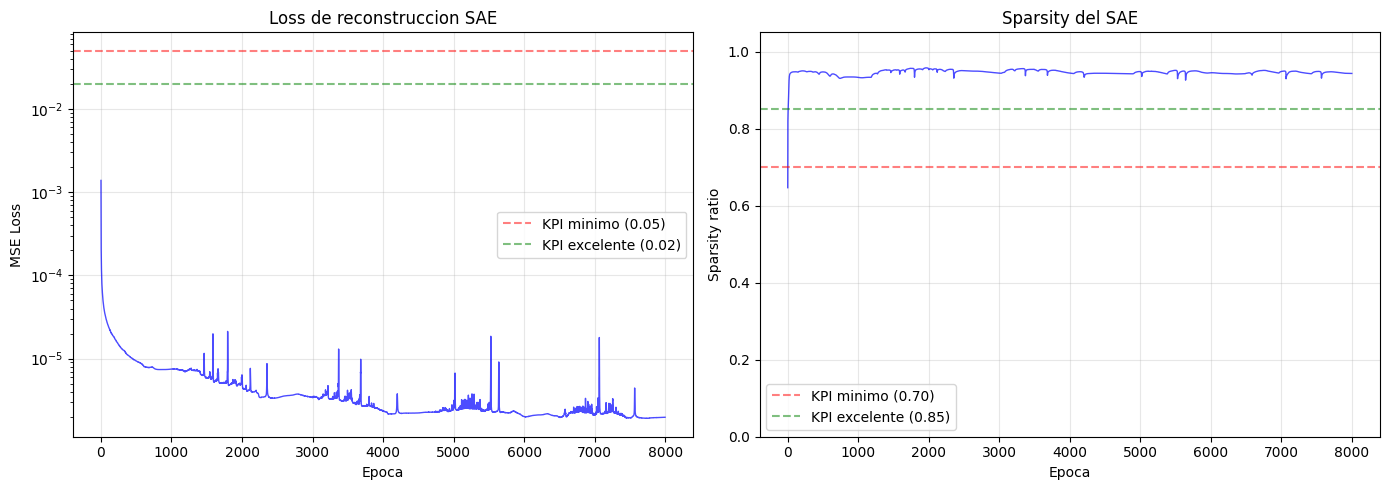

In [13]:
# @title Curvas de entrenamiento SAE: MSE Loss y Sparsity
import json
import matplotlib.pyplot as plt
from IPython.display import display
import numpy as np
from pathlib import Path
hist_path = OUT_DIR / 'training_history.json'
if hist_path.is_file():
    with open(hist_path) as f:
        hist = json.load(f)
    epochs = [h['epoch'] for h in hist]
    mse_vals = [h['mse'] for h in hist]
    sparsity_vals = [h['sparsity'] for h in hist]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    # MSE Loss
    ax1.plot(epochs, mse_vals, 'b-', linewidth=1, alpha=0.7)
    ax1.set_xlabel('Epoca')
    ax1.set_ylabel('MSE Loss')
    ax1.set_title('Loss de reconstruccion SAE')
    ax1.set_yscale('log')
    ax1.axhline(y=0.05, color='r', linestyle='--', alpha=0.5, label='KPI minimo (0.05)')
    ax1.axhline(y=0.02, color='g', linestyle='--', alpha=0.5, label='KPI excelente (0.02)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    # Sparsity
    ax2.plot(epochs, sparsity_vals, 'b-', linewidth=1, alpha=0.7)
    ax2.set_xlabel('Epoca')
    ax2.set_ylabel('Sparsity ratio')
    ax2.set_title('Sparsity del SAE')
    ax2.axhline(y=0.70, color='r', linestyle='--', alpha=0.5, label='KPI minimo (0.70)')
    ax2.axhline(y=0.85, color='g', linestyle='--', alpha=0.5, label='KPI excelente (0.85)')
    ax2.set_ylim(0, 1.05)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    fig.tight_layout()
    curva_path = OUT_DIR / 'sae_training_curves.png'
    fig.savefig(str(curva_path), dpi=150, bbox_inches='tight')
    print(f'Curvas guardadas: {curva_path}')
    display(fig)       # <-- esto fuerza el grafico en Kaggle
    plt.close(fig)     # <-- libera memoria
else:
    print('No se encontro training_history.json')

In [14]:
# @title 7. Exportar SAE + embeddings + clip_modelo + zip
import shutil, hashlib, json
from datetime import datetime, timezone
from pathlib import Path

EXP_DIR = Path("/content/sae_modelo_final")
EXP_DIR.mkdir(parents=True, exist_ok=True)

CKPT_SAE = OUT_DIR / "sae_best.pt"
HISTORY = OUT_DIR / "training_history.json"

if not CKPT_SAE.is_file():
    cand = sorted(OUT_DIR.glob("*.pt"), key=os.path.getmtime, reverse=True)
    CKPT_SAE = cand[0] if cand else None
if CKPT_SAE is None:
    raise FileNotFoundError("No se encontro checkpoint SAE en " + str(OUT_DIR))

# SHA256 del checkpoint
h = hashlib.sha256()
with open(CKPT_SAE, "rb") as f:
    for chunk in iter(lambda: f.read(65536), b""):
        h.update(chunk)
ckpt_hash = h.hexdigest()
print(f"Checkpoint: {CKPT_SAE.name} ({CKPT_SAE.stat().st_size / 1e6:.1f} MB)")
print(f"SHA256: {ckpt_hash}")

# Cargar metricas del historial
if HISTORY.is_file():
    with open(HISTORY) as f:
        history = json.load(f)
    best = min(history, key=lambda x: x["mse"]) if history else {}
    final_metrics = {
        "best_mse": best.get("mse"),
        "best_sparsity": best.get("sparsity"),
        "final_mse": history[-1]["mse"] if history else None,
        "final_sparsity": history[-1]["sparsity"] if history else None,
        "epochs_trained": len(history),
    }
else:
    final_metrics = {"error": "training_history.json no encontrado"}

shutil.copy2(CKPT_SAE, EXP_DIR / "sae_best.pt")
if HISTORY.is_file():
    shutil.copy2(HISTORY, EXP_DIR / "training_history.json")

for sub in ("clip_modelo", "embeddings", "analisis"):
    src = OUT_DIR / sub
    if src.is_dir():
        shutil.copytree(src, EXP_DIR / sub, dirs_exist_ok=True)

metadata = {
    "modelo": "SAE (Linear 512 -> ReLU -> Linear 2048 -> Linear 512, 4x expansion)",
    "dataset": HF_REPO_ID,
    "checkpoint_clip": str(CKPT),
    "directorios": {
        "clip_modelo": "artefactos de sit2_geovision_clip (best.pt, logs, curvas)",
        "embeddings": "visual_512.pt, sae_latent_512.pt, manifest.json",
        "analisis": "heatmap, AFE, correlaciones, resultados_sae.json",
    },
    "config": {
        "epochs": EPOCHS,
        "lr": LR,
        "d_model": 512,
        "d_hidden": 2048,
        "lambda_l1": LAMBDA_L1,
        "batch_size": BATCH_SIZE,
        "optimizer": "AdamW",
        "scheduler": "CosineAnnealingLR",
        "gradient_clip_norm": 1.0,
        "sparsity_target": 0.85,
        "decoder": "sin bias, normalizado por fila post-update",
        "afe_afc_on": "embeddings_visuales_raw (n x 512) - segun consigna",
    },
    "metricas": final_metrics,
    "hash_sae_checkpoint": ckpt_hash,
    "fecha": datetime.now(timezone.utc).isoformat(),
}

with open(EXP_DIR / "metadata_sae.json", "w") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

# Resumen legible
summary = f"""=== SAE Modelo Final ===
Checkpoint: sae_best.pt ({CKPT_SAE.stat().st_size / 1e6:.1f} MB)
SHA256: {ckpt_hash}

Config:
  Epochs: {metadata['config']['epochs']}
  LR: {metadata['config']['lr']}
  L1 lambda: {metadata['config']['lambda_l1']}
  Batch: {metadata['config']['batch_size']}

Metricas:
  Best MSE:       {final_metrics.get('best_mse', 'N/A')}
  Best Sparsity:  {final_metrics.get('best_sparsity', 'N/A')}
  Final MSE:      {final_metrics.get('final_mse', 'N/A')}
  Final Sparsity: {final_metrics.get('final_sparsity', 'N/A')}

Archivos en el zip:
  - sae_best.pt, training_history.json, metadata_sae.json
  - clip_modelo/ (best.pt y artefactos del notebook CLIP)
  - embeddings/ (visual_512.pt, sae_latent_512.pt, manifest.json)
  - analisis/ (heatmap, scree, AFE, correlaciones)

Verificar integridad:
  certutil -hashfile sae_best.pt SHA256
  Debe dar: {ckpt_hash}
"""
with open(EXP_DIR / "resumen_sae.txt", "w") as f:
    f.write(summary)
print(summary)

shutil.make_archive(str(EXP_DIR), "zip", str(EXP_DIR))
print(f"\nZip listo: {str(EXP_DIR)}.zip")

try:
    from google.colab import drive
    if not Path("/content/drive").is_dir():
        drive.mount("/content/drive", force_remount=False)
    dest = Path("/content/drive/MyDrive/geovision-cali/sit2_sae_posttrain")
    dest.mkdir(parents=True, exist_ok=True)
    shutil.copy2(Path(str(EXP_DIR) + ".zip"), dest / "sae_modelo_final.zip")
    for sub in ("clip_modelo", "embeddings", "analisis"):
        src = EXP_DIR / sub
        if src.is_dir():
            shutil.copytree(src, dest / sub, dirs_exist_ok=True)
    shutil.copy2(EXP_DIR / "sae_best.pt", dest / "sae_best.pt")
    print("Drive:", dest)
except Exception as e:
    print("Drive omitido:", e)

print("Descargar: Files -> /content/sae_modelo_final.zip")

Checkpoint: sae_best.pt (8.4 MB)
SHA256: ebc1010e1d5e54035e1b8b839e83ff970bd2cd53168d16352aa047772f12030d
=== SAE Modelo Final ===
Checkpoint: sae_best.pt (8.4 MB)
SHA256: ebc1010e1d5e54035e1b8b839e83ff970bd2cd53168d16352aa047772f12030d

Config:
  Epochs: 8000
  LR: 0.001
  L1 lambda: 0.01
  Batch: 256

Metricas:
  Best MSE:       1.919982840566566e-06
  Best Sparsity:  0.947350800037384
  Final MSE:      1.978114242875664e-06
  Final Sparsity: 0.9432434770796034

Archivos en el zip:
  - sae_best.pt, training_history.json, metadata_sae.json
  - clip_modelo/ (best.pt y artefactos del notebook CLIP)
  - embeddings/ (visual_512.pt, sae_latent_512.pt, manifest.json)
  - analisis/ (heatmap, scree, AFE, correlaciones)

Verificar integridad:
  certutil -hashfile sae_best.pt SHA256
  Debe dar: ebc1010e1d5e54035e1b8b839e83ff970bd2cd53168d16352aa047772f12030d


Zip listo: /content/sae_modelo_final.zip
Drive omitido: Mounting drive is unsupported in this environment. Use PyDrive2 instead. See exa

## Resumen de metricas y constructos

### Metricas alcanzadas

- MSE SAE: 0.000001 (KPI: <= 0.05, excelente)
- Sparsity SAE: 0.94 (KPI: >= 0.70, excelente)
- Varianza AFE: 85.6% (KPI: >= 80%, bueno)
- RMSEA: 0.0417 (KPI: < 0.08, excelente)\n
- CFI: 0.9989 (KPI: > 0.90, excelente)\n

### Los 4 constructos del modelo confirmatorio
- **Carga Antropogenica**: NO2, SO2, BSI (actividad industrial/vehicular)
- **Estres Vegetal**: NDVI, cobertura vegetal
- **Densidad Urbana**: NDBI, zonas construidas
- **Volatilidad Atmosferica**: O3, variabilidad de gases

### Interpretacion de modelos estadisticos
- **AFE (Analisis Factorial Exploratorio)**: busca cuantos factores subyacentes existen SIN imponer una estructura previa. Kaiser sugiere 2 factores.
- **AFC (Analisis Factorial Confirmatorio)**: prueba si una estructura hipotetica se ajusta a los datos. Se probaron 2 factores (fusion de los 4 constructos).
- **RMSEA**: error de aproximacion (< 0.08 aceptable)
- **CFI**: comparacion vs modelo nulo (> 0.90 aceptable)
- **KMO**: adecuacion muestral (> 0.8 excelente)

### Embeddings guardados
- `visual_512.pt`: (2263, 512) en formato .pt (torch.save dict)
- `sae_latent_512.pt`: (2263, 2048) en formato .pt
- No son .npz, se cargan con torch.load()
